# ML pipeline for UNO

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision.io import decode_image
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader

from ML_utils import *
from image_utils import *

First let us define some useful global variables :
- File paths to the data
- Translations from text to vector representation
- ML hyperparameters

In [2]:
# Filenames to access data
img_dir = os.path.join("iapr-26-uno-vision-challenge", "train_images")
annotations_file = os.path.join("iapr-26-uno-vision-challenge", "train") + '.csv'
checkpoint_dir = "checkpoints"
checkpoint_model_name = "model_test"
if (not os.path.exists(checkpoint_dir)):
    os.mkdir(checkpoint_dir)
checkpoint_path = os.path.join(checkpoint_dir, checkpoint_model_name) + '.pt'

# List of cards : digits (0 to 9) with color, specials (draw_2, reverse, skip) with color, other special (draw_4, wild)
card_name_list = [str(color) + '_' + str(digit) for digit in range(10) for color in ['r', 'g', 'b', 'y']]
card_name_list += [str(color) + '_' + str(special) for special in ['draw_2', 'reverse', 'skip'] for color in ['r', 'g', 'b', 'y']]
card_name_list += ['draw_4', 'wild']
# Mapping from card name to its index in vector form
card_name_to_index = {card_name : index for index, card_name in enumerate(card_name_list)}

# General ML parameters :
torch.manual_seed(0)
train_val_test_split = [0.7, 0.15, 0.15]
learning_rate = 0.0001
weight_decay = 0.01
batch_size = 16
nb_epochs = 200
p_dropout = 0.2

RGB_normalization_mean = torch.tensor([0.485, 0.456, 0.406])
RGB_normalization_std = torch.tensor([0.229, 0.224, 0.225])
transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=RGB_normalization_mean, std=RGB_normalization_std),
])

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

Using device cpu


Then let us define helper functions to handle transformations between data and ML model.

In [4]:
def output_transform(model_output):
    return model_output.softmax(dim=1)

def label_string_to_tensor(label):
    # Give the model representation from the label annotation :
    output = torch.zeros(len(card_name_list) + 1)
    if (label == 'EMPTY'):
        output[-1] = 1
    else:
        for card_name in label.split(";"):
            output[card_name_to_index[card_name]] += 1
    output = output / torch.sum(output)
    return output

def label_tensor_to_string(vector):
    # Give the label annotation from the model representation :
    card_name_list_completed = card_name_list + ['EMPTY']
    card_list = []
    # Go from probabilities to number of cards
    vector_list = list((1.49 * vector / torch.max(vector)).flatten())
    for index, value in enumerate(vector_list):
        nb_cards = round(value.item())
        while (nb_cards > 0):
            card_list.append(card_name_list_completed[index])
            nb_cards -= 1
    output = ';'.join(card_list)
    return output

def image_reverse_RGB_normalization(img):
    RGB_std = RGB_normalization_std.reshape((3,1,1)).to(img.device)
    RGB_mean = RGB_normalization_mean.reshape((3,1,1)).to(img.device)
    return (255*(img * RGB_std + RGB_mean)).to(torch.uint8)

Image shape torch.Size([3, 2662, 4000])
Divided image shape torch.Size([3, 886, 2228])


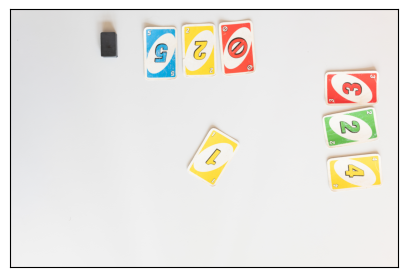

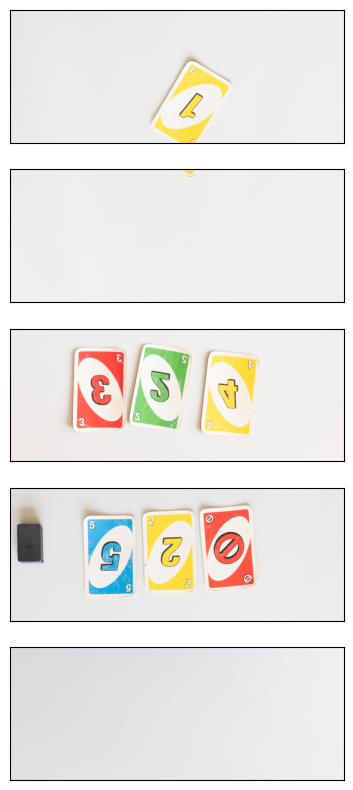

In [5]:
# Take a look a the image in the dataset
full_image_example = decode_image(os.path.join(img_dir, 'L1000770.jpg'))
print(f"Image shape {full_image_example.shape}")
divided_images_example = [divide_image(full_image_example, i) for i in range(5)]
print(f"Divided image shape {divided_images_example[0].shape}")

display_tensor_images(full_image_example)
display_tensor_images(divided_images_example, transform=None, shape=(1, len(divided_images_example)), figsize=(5,10))

In [6]:
class UNOImageDataset(Dataset):
    def __init__(self, img_dir, annotations_file, divide_image, label_string_to_tensor, transform=None, device='cpu'):
        # Annotations contains : 'image_id', 'center_card', 'active_player', 'player_1_cards', 'player_2_cards', 'player_3_cards', 'player_4_cards'
        annotations = pd.read_csv(annotations_file)
        self.device = device
        self.transform = transform
        # Store image labels
        self.img_labels = torch.zeros((5*len(annotations['image_id']), len(card_name_list) + 1), dtype=torch.float32)
        self.img_labels[0::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['center_card']])
        self.img_labels[1::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_1_cards']])
        self.img_labels[2::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_2_cards']])
        self.img_labels[3::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_3_cards']])
        self.img_labels[4::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_4_cards']])
        # Store images
        self.imgs = torch.zeros((5*len(annotations['image_id']), 3, 886, 2228), dtype=torch.uint8)
        for img_index in range(len(annotations['image_id'])):
            img_path = os.path.join(img_dir, annotations['image_id'][img_index]) + '.jpg'
            full_image = decode_image(img_path)
            for divided_img_index in range(5):
                self.imgs[img_index*5 + divided_img_index] = divide_image(full_image, divided_img_index)

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        image = self.imgs[idx]
        if (self.transform != None):
            image = self.transform(image)
        image = image.to(self.device)
        label = self.img_labels[idx].to(self.device)
        return image, label

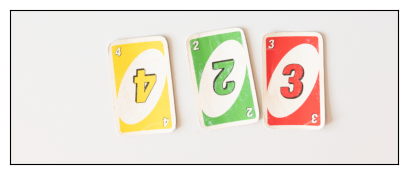

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.3333, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000])
g_2;r_3;y_4


In [7]:
full_dataset = UNOImageDataset(img_dir, annotations_file, divide_image, label_string_to_tensor, transform=transforms, device=device)
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(full_dataset, train_val_test_split, generator=torch.Generator().manual_seed(42))

# Display sample
image_sample, label_sample = full_dataset.__getitem__(2)
with torch.no_grad():
    display_tensor_images(image_sample, transform=image_reverse_RGB_normalization)
    print(label_sample)
    print(label_tensor_to_string(label_sample))

In [8]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, generator=torch.Generator().manual_seed(42))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, generator=torch.Generator().manual_seed(42))

## Define the model

In [9]:
class UNO_Model(nn.Module):
    def __init__(self):
        super().__init__()
        # Recall shape 3, 886, 2228
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(6), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(6), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(16), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2))
        self.layer4 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(16), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2))
        self.layer5 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2))
        self.layer6 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2))
        self.layer7 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2))
    
        self.dropout = nn.Dropout(p_dropout)
        
        self.classifier = nn.Sequential(
            nn.Linear(32 * 2 * 13, 256), 
            #nn.BatchNorm1d(256), 
            nn.ReLU(inplace=True), 
            nn.Linear(256, 128), 
            #nn.BatchNorm1d(128), 
            nn.ReLU(inplace=True), 
            nn.Linear(128, 55), 
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.dropout(x)
        x = self.layer3(x)
        x = self.dropout(x)
        x = self.layer4(x)
        x = self.dropout(x)
        x = self.layer5(x)
        x = self.dropout(x)
        x = self.layer6(x)
        x = self.dropout(x)
        x = self.layer7(x)
        x = self.dropout(x)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        #x = self.dropout(x)
        x = self.classifier(x)
        return x

model = UNO_Model()
torch.manual_seed(0)
model.apply(init_weights)
model = model.to(device)
print(model)
print(f"Number of parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

UNO_Model(
  (layer1): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(6, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer4): Sequential(
    (0): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1,

In [10]:
with torch.no_grad():
    print(output_transform(model(image_sample.unsqueeze(0))))
    print(label_sample)

tensor([[0.0131, 0.0121, 0.0276, 0.0237, 0.0284, 0.0119, 0.0093, 0.0348, 0.0645,
         0.0321, 0.0053, 0.0082, 0.0094, 0.0090, 0.0064, 0.0083, 0.0217, 0.0031,
         0.0033, 0.0180, 0.0337, 0.0140, 0.0169, 0.0061, 0.0029, 0.0418, 0.0056,
         0.0427, 0.0167, 0.0099, 0.0073, 0.1277, 0.0064, 0.0369, 0.0044, 0.0055,
         0.0045, 0.0153, 0.0284, 0.0636, 0.0160, 0.0044, 0.0124, 0.0095, 0.0137,
         0.0050, 0.0041, 0.0111, 0.0147, 0.0097, 0.0056, 0.0161, 0.0082, 0.0125,
         0.0166]])
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.3333, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000]

## Train the model

In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, nb_epochs)

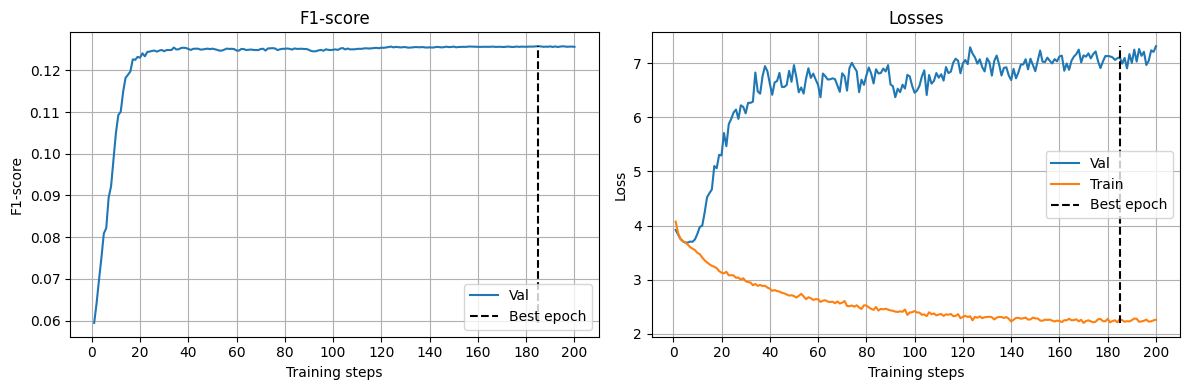

100%|█████████████████████████████████████████████████████████████████████████████| 200/200 [7:06:52<00:00, 128.06s/it]

Current train loss = 2.2598123484187655, current validation loss = 7.317242860794067, current validation f1 loss = 0.12563259154558182
Best model at epoch 185 -> 12.58% F1 score


In [12]:
train_output = train(model, train_loader, val_loader, nb_epochs, optimizer, scheduler, loss_fn, output_transform, checkpoint_path, show_plot=True)
best_model, best_f1, best_epoch, val_f1s, val_losses, train_losses = train_output
print(f"Best model at epoch {best_epoch} -> {100*best_f1:.2f}% F1 score")

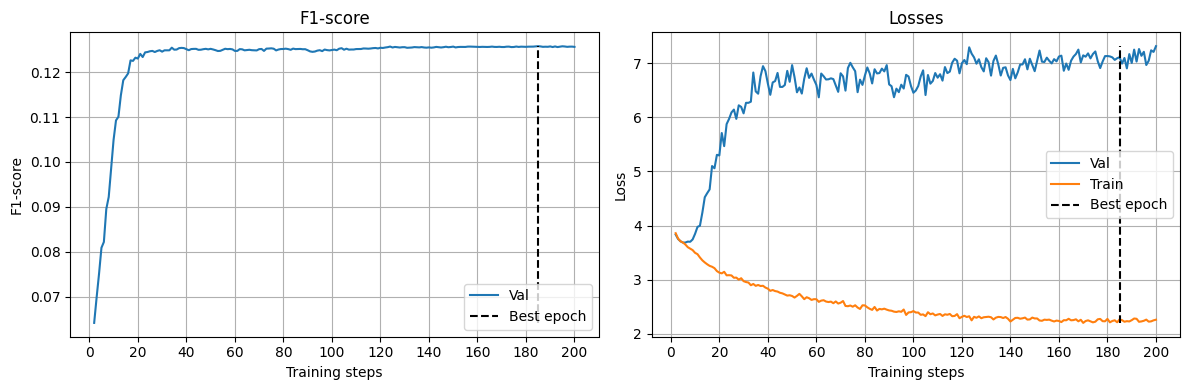

In [13]:
plot_training(best_epoch, val_f1s, val_losses, train_losses, first_epoch_plot=2)

In [14]:
with torch.no_grad():
    model = UNO_Model().to(device)
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    label_predict = output_transform(model(image_sample.unsqueeze(0)))
    print(label_predict)
    print(label_tensor_to_string(label_predict))
    print(label_sample)
    print(label_tensor_to_string(label_sample))

tensor([[8.5849e-04, 4.5087e-04, 1.0940e-05, 4.3782e-06, 1.9543e-04, 1.3813e-03,
         4.2521e-06, 1.0010e-05, 1.0040e-05, 3.7631e-04, 6.6138e-06, 2.1521e-06,
         4.1007e-05, 1.6341e-04, 1.4996e-06, 1.2026e-06, 5.0408e-05, 1.8648e-04,
         1.9190e-05, 1.5017e-06, 2.5938e-04, 3.6921e-04, 4.8863e-06, 6.7910e-07,
         2.0372e-04, 4.4139e-05, 2.2067e-06, 2.8610e-06, 2.7430e-03, 5.5805e-04,
         1.1486e-06, 6.2695e-05, 6.9957e-04, 3.0645e-04, 4.7367e-06, 1.3717e-05,
         8.7813e-04, 5.3073e-07, 2.0030e-06, 3.2489e-06, 8.1599e-05, 5.5411e-06,
         4.7395e-05, 2.1778e-04, 1.2824e-05, 1.6202e-04, 4.2327e-07, 9.4913e-07,
         3.9709e-05, 2.6020e-03, 2.9236e-07, 3.9660e-08, 1.9933e-04, 2.5256e-04,
         9.8644e-01]])
EMPTY
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.3333, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
  